In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import skimage
from matplotlib import pyplot as plt
import os
import json

In [2]:
ROOT = Path("/Users/kvying/Files/rothmanlab")
DATA = ROOT / "rothman-data/sam-imaging"
CURRDATA = DATA / "03-27-2026/movies!!"

In [43]:
img = plt.imread(CURRDATA / "Overview 2 - 3630_commastage - 15_11_23 - 1.ome.tiff")

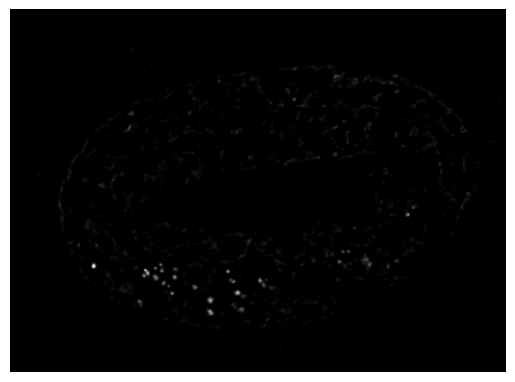

In [44]:
plt.axis('off')
plt.imshow(img[:,:,0], cmap='gray')

In [46]:
img = img[:,:,0]

In [6]:
th = skimage.filters.threshold_isodata(img)

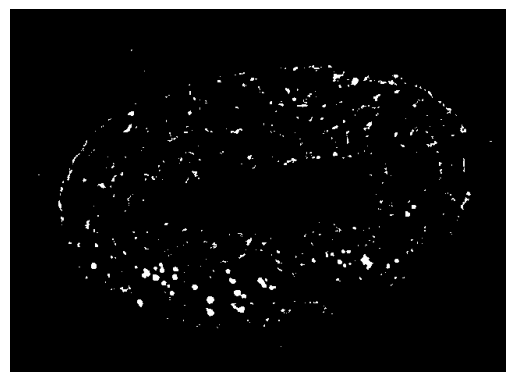

In [47]:
plt.axis('off')
plt.imshow(img > th, cmap='gray')

In [8]:
objs = skimage.measure.label(img>th)

In [9]:
circs = []

In [10]:
measure = skimage.measure.regionprops(objs)
for m in measure:
	if m['area'] > 10 and 0 < m['eccentricity'] < 0.7:
		print(m['label'], m['area'], m['eccentricity'])
		circs.append(m['label'])

17 22.0 0.6581769141245466
22 68.0 0.6765623103275747
56 19.0 0.46240219449488373
71 15.0 0.35152553213947263
82 28.0 0.6649869621674982
85 19.0 0.5964611617767742
170 26.0 0.4360120766419678
181 17.0 0.625943231252129
215 11.0 0.6714847803042769
227 15.0 0.44916323740876424
237 21.0 0.5593699317494591
250 11.0 0.5913123959890826
257 27.0 0.4980834331416218
262 36.0 0.5732568543933604
334 19.0 0.5207037318817048
336 20.0 0.6967121764893405
342 17.0 0.4984185516527038
354 25.0 0.4984711566327377
356 31.0 0.555928406605324
361 49.0 0.49962268092561496
366 17.0 0.625943231252129
369 11.0 0.5097856874585104
372 18.0 0.41652044217833617
373 34.0 0.6408497864039361
375 91.0 0.5826401017387395
376 29.0 0.3771219322706113
384 43.0 0.511396002211497
386 60.0 0.507100804406578
397 32.0 0.3964556356716313
401 13.0 0.5081397159034496
402 43.0 0.4770252668456058
409 29.0 0.3757492863864437
412 74.0 0.21631687480448528
427 17.0 0.46826450377252443


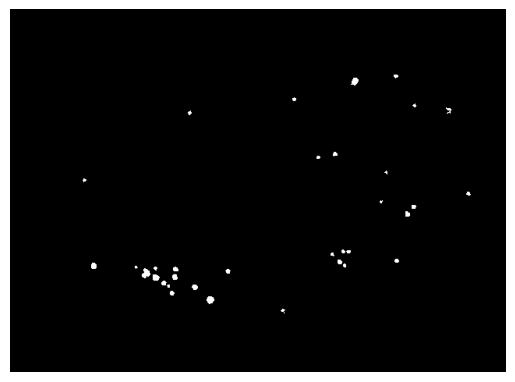

In [41]:
plt.axis('off')
plt.imshow(np.isin(objs, circs), cmap='gray')

In [12]:
import imagej
import scyjava

In [13]:
ij = imagej.init('net.imagej:imagej:2.14.0', mode='interactive')

jar tool not found at /Users/kvying/Library/Caches/cjdk/v0/jdks/1145ecba33093381df8521c89dbd0bcb1d3c92d7/zulu11.86.19-ca-jre11.0.30-macosx_aarch64/bin/jar


In [14]:
Line = scyjava.jimport('ij.gui.Line')

In [15]:
p = str(CURRDATA / "Overview 2 - 3630_commastage - 15_11_23 - 1.ome.tiff")
imp = ij.IJ.openImage("https://imagej.net/images/blobs.gif")

In [ ]:
def plotfluorprofile(img: np.ndarray | str, startxy: tuple, endxy: tuple):
	if type(img) == str:
		imp = ij.IJ.openImage(img)
	elif type(img) == np.ndarray:
		imp = ij.py.to_imageplus(img)
	coords = list(startxy + endxy)
	line_roi = Line(*coords)
	imp.setRoi(line_roi)

	profile = np.array(line_roi.getPixels())

	img_array = ij.py.from_java(imp)

	fig, ax = plt.subplots(1, 2, figsize=(12, 5))

	ax[0].imshow(img_array, cmap='gray')
	ax[0].plot([coords[0], coords[2]], [coords[1], coords[3]], color='red', linewidth=2)
	ax[0].axis('off')

	ax[1].plot(profile, color='black')
	ax[1].set_xlabel("distance")
	ax[1].set_ylabel("intensity")

	plt.tight_layout()

	return profile

<class 'str'>


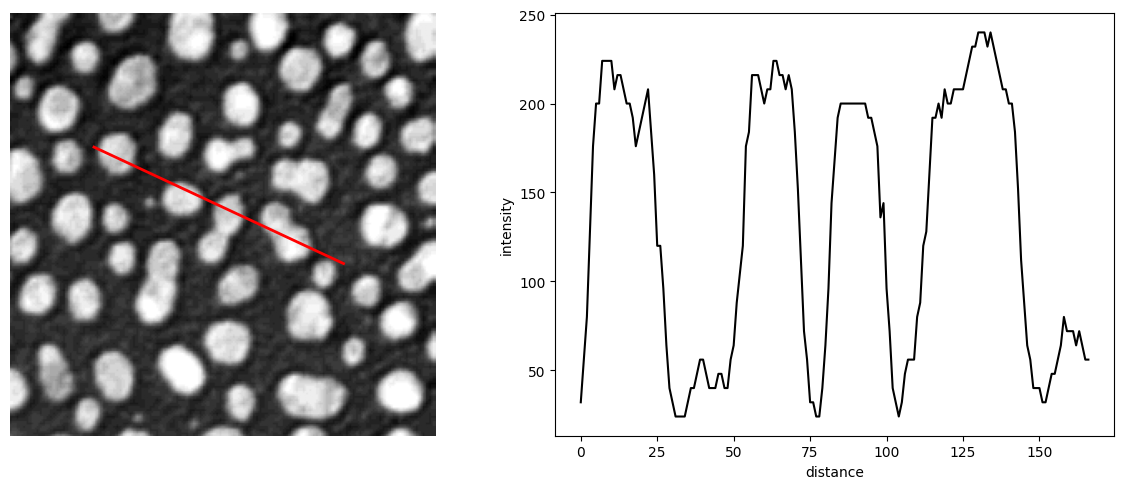

In [39]:
x = plotfluorprofile("https://imagej.net/images/blobs.gif", (50,80), (200,150))